# Customer Intelligence System using Clustering and Ensemble Learning

## Project Overview

In this project, country-level socio-economic and health indicators are analyzed to identify meaningful groups of countries. Different clustering techniques are used to segment countries, and ensemble learning models are applied to classify the generated segments.

### Techniques Used
- K-Means Clustering
- K-Medoids Clustering
- DBSCAN
- Hierarchical Clustering
- Random Forest
- XGBoost

### Objective
The main goal is to discover patterns among countries and build a system that can automatically identify similar country groups based on their characteristics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Quick Inspection

Before applying clustering techniques, let's understand the structure of the dataset and check for any missing values or inconsistencies.

In [3]:
print("Shape of Dataset:", df.shape)
print("\n")

df.info()

Shape of Dataset: (167, 10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [5]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## Data Cleaning

The dataset does not contain missing values. However, basic checks are performed to ensure data quality before clustering.

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## Exploratory Data Analysis

To better understand the dataset, we analyze the distribution of features and relationships among variables.

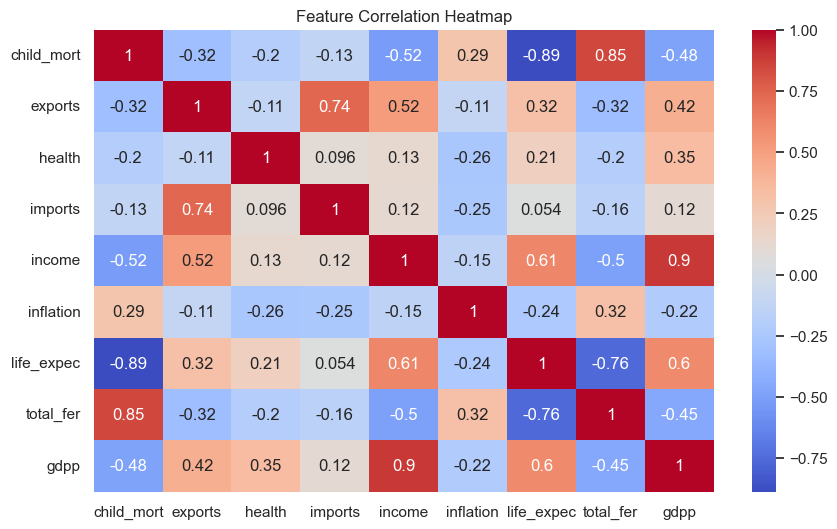

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop("country", axis=1).corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

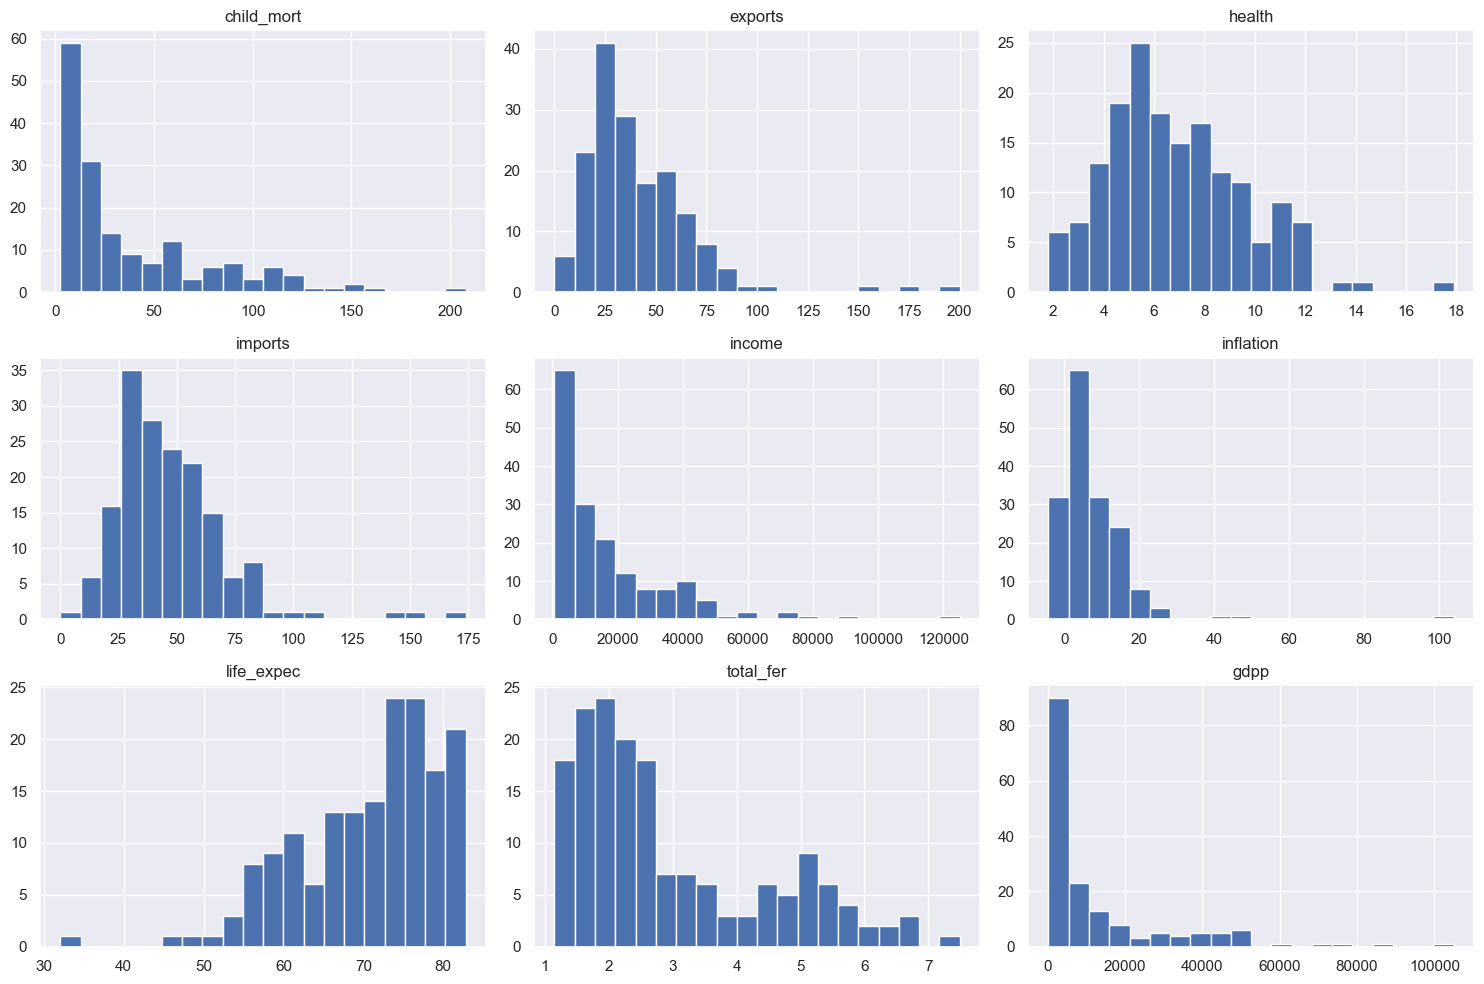

In [8]:
df.drop("country", axis=1).hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

## Feature Scaling

Since the features are measured on different scales, standardization is applied before clustering to ensure that all variables contribute equally.

In [9]:
from sklearn.preprocessing import StandardScaler

X = df.drop("country", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(167, 9)


## K-Means Clustering

K-Means clustering is used to group countries with similar socio-economic characteristics.

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

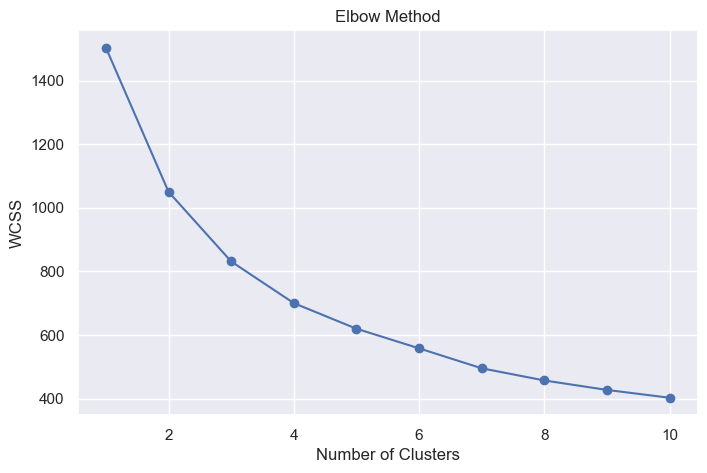

In [11]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [12]:
import warnings
warnings.filterwarnings("ignore")

## K-Means Clustering

K-Means is one of the most widely used clustering algorithms. It groups countries into clusters based on similarities in their socio-economic and health indicators. The optimal number of clusters was selected using the Elbow Method.

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

df[["country", "KMeans_Cluster"]].head()

,country,KMeans_Cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


## PCA Visualization

To visualize the clusters in a two-dimensional space, Principal Component Analysis (PCA) is applied. This helps in understanding how countries are grouped by the clustering algorithm.

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = df["KMeans_Cluster"]

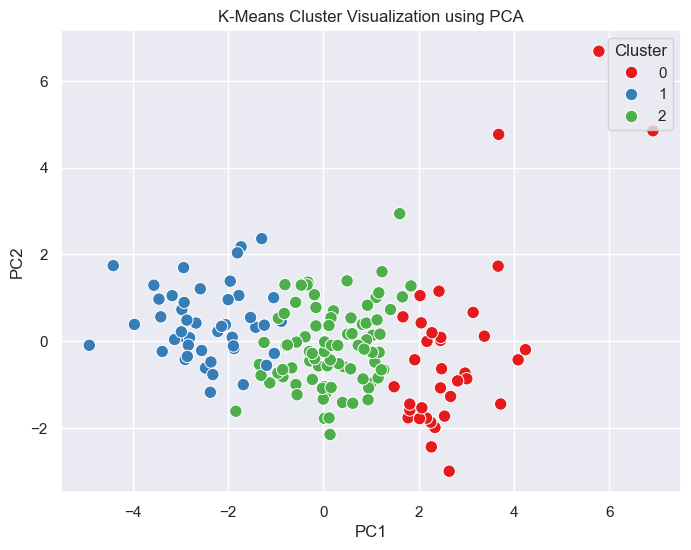

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("K-Means Cluster Visualization using PCA")
plt.show()

## Cluster Profiling

After creating clusters, the average values of features within each cluster are examined to understand the characteristics of different country groups.

In [17]:
cluster_profile = df.groupby("KMeans_Cluster").mean(numeric_only=True)

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


## DBSCAN Clustering

DBSCAN is a density-based clustering technique that groups similar countries together and also identifies possible outliers.

In [20]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.5, min_samples=5)

df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

df[["country", "DBSCAN_Cluster"]].head()

,country,DBSCAN_Cluster
0,Afghanistan,0
1,Albania,0
2,Algeria,0
3,Angola,0
4,Antigua and Barbuda,0


## Hierarchical Clustering

Hierarchical Clustering creates a tree-like structure of clusters and helps understand how countries are grouped at different levels of similarity.

In [21]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)

df["Hierarchical_Cluster"] = hc.fit_predict(X_scaled)

df[["country","Hierarchical_Cluster"]].head()

,country,Hierarchical_Cluster
0,Afghanistan,2
1,Albania,1
2,Algeria,1
3,Angola,1
4,Antigua and Barbuda,1


In [22]:
df.groupby("Hierarchical_Cluster").mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_Cluster,DBSCAN_Cluster
Hierarchical_Cluster,,,,,,,,,,,
0,5.961765,58.508824,8.501176,48.902941,47588.235294,4.115500,79.982353,1.888529,43170.588235,0.176471,-0.117647
1,31.617925,39.990368,6.353679,48.085527,11341.886792,9.120604,70.921698,2.654623,6407.367925,1.716981,-0.009434
2,105.070370,23.589630,6.507037,39.662963,1589.740741,7.142778,57.248148,5.433704,667.888889,1.000000,-0.037037


# Classification and Ensemble Learning

The clusters generated by K-Means are now used as target labels. Classification models are trained to predict the cluster category of countries based on their features.


In [23]:
from sklearn.model_selection import train_test_split

X = df.drop(
    ["country","KMeans_Cluster","DBSCAN_Cluster","Hierarchical_Cluster"],
    axis=1
)

y = df["KMeans_Cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9705882352941176


In [25]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      1.00      0.92         6
           2       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



## Gradient Boosting

As XGBoost was taking time to run in the local environment, Gradient Boosting is used as another ensemble model for comparison.

In [28]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, gb_pred))

Gradient Boosting Accuracy: 1.0


In [29]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00        20

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



## Model Comparison

Both ensemble models performed well on the dataset. Random Forest achieved high accuracy, while Gradient Boosting provided the best performance on the test set.

| Model | Accuracy |
|---------|---------|
| Random Forest | 97% |
| Gradient Boosting | 100% |

## Confusion Matrix

A confusion matrix is used to compare the actual cluster labels with the predicted labels.

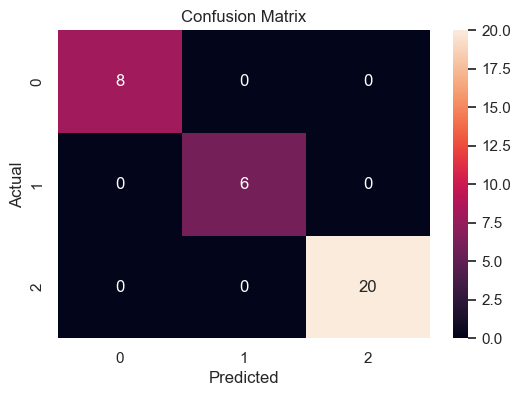

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Final Insights

- K-Means created clear groups of countries based on socio-economic indicators.
- Countries with higher income and GDP were grouped separately from developing countries.
- DBSCAN and Hierarchical Clustering provided additional clustering perspectives.
- Random Forest and Gradient Boosting successfully predicted the generated cluster labels.
- Gradient Boosting achieved the highest accuracy on the test data.

## Conclusion

In this project, clustering techniques were used to segment countries based on socio-economic and health indicators. K-Means, DBSCAN, and Hierarchical Clustering were applied to identify meaningful groups.

The cluster labels generated by K-Means were then used for classification. Random Forest and Gradient Boosting models were trained and evaluated. Both models performed well, with Gradient Boosting achieving the best results.

This project demonstrates how clustering and ensemble learning can be combined to build a simple intelligence system for data segmentation and prediction.